# SIDIS plots and studies

Generate plots for the SIDIS framework. Run tests and studies on implemented code.

Sections:
1. Plot mock kinematics from file
2. Plot cross sections from mock kinematics.

3. Study the bT-shapes of the PDF and FF NP
4. Check that the model can be initialized correctly

## Initializations

In [1]:
# Setup and imports
import sys
import pathlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# Add parent directory to path so sidis can be imported as a package
parent_dir = pathlib.Path().resolve().parent.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from sidis.model import TrainableModel
from sidis.utilities.colors import tcolors

# Set default tensor dtype to float64 for high precision
torch.set_default_dtype(torch.float64)

print(f"{tcolors.GREEN}Setup complete!{tcolors.ENDC}")
print(f"PyTorch version: {torch.__version__}")
print(f"Default dtype: {torch.get_default_dtype()}")

Setup complete!
PyTorch version: 2.6.0
Default dtype: torch.float64


### Create and set needed folders


In [2]:
# Folder to save the plots. If it does not exist, create it.
plots_dir = pathlib.Path().resolve() / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Set the kinematics data folder, contains the generated kinematics
kin_dir = pathlib.Path().resolve() / "kin/"
if not kin_dir.exists():
    print(f"{tcolors.FAIL}Kinematics data folder not found: {kin_dir}{tcolors.ENDC}")
    print(f"{tcolors.FAIL}Run the generate_mock_kinematics.py script first.{tcolors.ENDC}")
    raise FileNotFoundError(f"{tcolors.FAIL}Kinematics data folder not found: {kin_dir}{tcolors.ENDC}")


In [4]:
# Events data folder, contains the generated events
events_dir = pathlib.Path().resolve() / "events/"
if not events_dir.exists():
    print(f"{tcolors.FAIL}Events data folder not found: {events_dir}{tcolors.ENDC}")
    print(f"{tcolors.FAIL}Run the generate_mock_events.py script first.{tcolors.ENDC}")
    raise FileNotFoundError(f"{tcolors.FAIL}Events data folder not found: {events_dir}{tcolors.ENDC}")

## Section 1: Plot Mock Kinematics

Visualize the distributions of the generated kinematic variables (x, PhT, Q, z), starting from files in the `kin` folder.

In [5]:
# Get file(s) to plot. Assume they are in the `kin` folder.
kin_file = kin_dir / "mock_kinematics_10000.pt"

# Load the data
data = torch.load(kin_file)

# Kinematic variables
x_plot = data[:, 0].numpy()
PhT_plot = data[:, 1].numpy()
Q_plot = data[:, 2].numpy()
z_plot = data[:, 3].numpy()

# Get number of kinematic points
n_kin_points = data.shape[0]


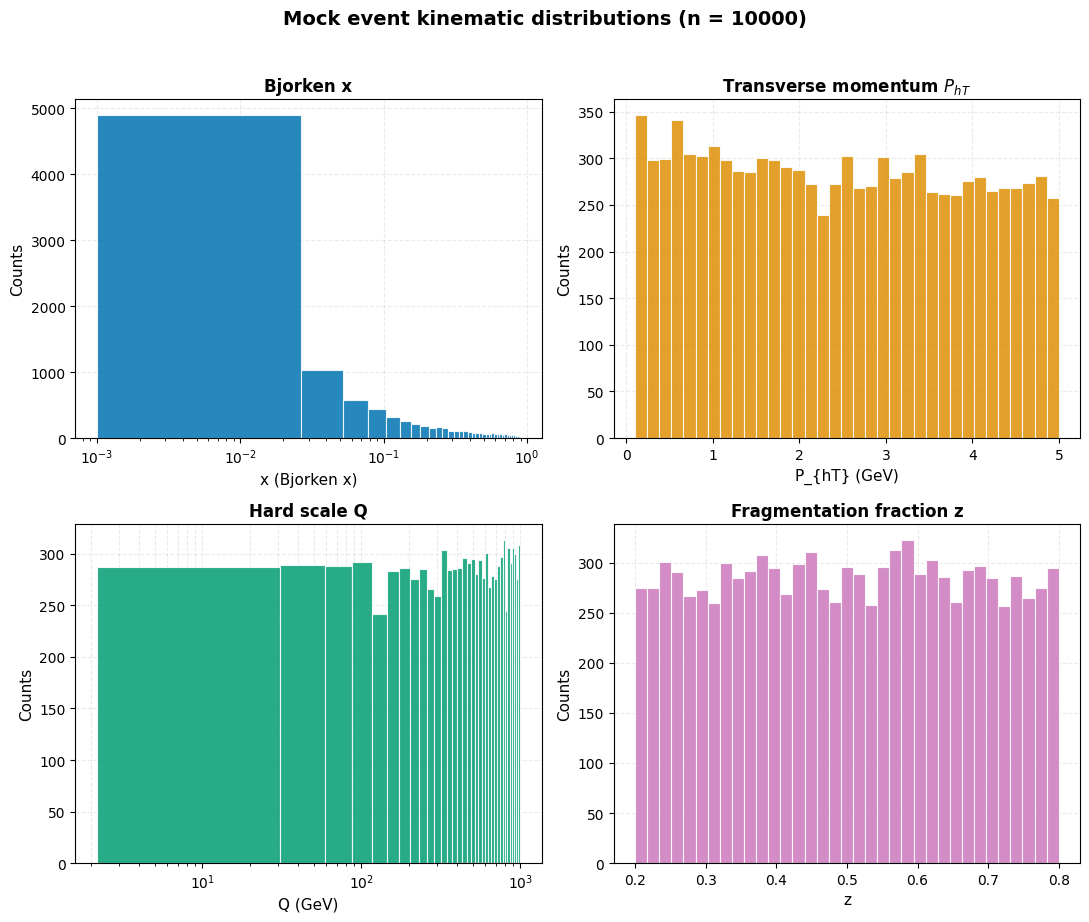

In [6]:
# Distinct colors per variable for clarity (colorblind-friendly)
colors = ["#0173b2", "#de8f05", "#029e73", "#cc78bc"]  # blue, orange, green, purple
labels = ["x (Bjorken x)", "P_{hT} (GeV)", "Q (GeV)", "z"]

# Create the plots
fig, axes = plt.subplots(2, 2, figsize=(11, 9), facecolor="white")

# Plot the x distribution
axes[0, 0].hist(x_plot, bins=35, color=colors[0], edgecolor="white", linewidth=0.8, alpha=0.85)
axes[0, 0].set_xlabel(labels[0], fontsize=11)
axes[0, 0].set_ylabel("Counts", fontsize=11)
axes[0, 0].set_title("Bjorken x", fontsize=12, fontweight="bold")
axes[0, 0].set_xscale("log")
axes[0, 0].grid(True, alpha=0.25, linestyle="--")
axes[0, 0].set_axisbelow(True)

# Plot the PhT distribution
axes[0, 1].hist(PhT_plot, bins=35, color=colors[1], edgecolor="white", linewidth=0.8, alpha=0.85)
axes[0, 1].set_xlabel(labels[1], fontsize=11)
axes[0, 1].set_ylabel("Counts", fontsize=11)
axes[0, 1].set_title(r"Transverse momentum $P_{hT}$", fontsize=12, fontweight="bold")
axes[0, 1].grid(True, alpha=0.25, linestyle="--")
axes[0, 1].set_axisbelow(True)

# Plot the Q distribution
axes[1, 0].hist(Q_plot, bins=35, color=colors[2], edgecolor="white", linewidth=0.8, alpha=0.85)
axes[1, 0].set_xlabel(labels[2], fontsize=11)
axes[1, 0].set_ylabel("Counts", fontsize=11)
axes[1, 0].set_title("Hard scale Q", fontsize=12, fontweight="bold")
axes[1, 0].set_xscale("log")
axes[1, 0].grid(True, alpha=0.25, linestyle="--", which="both")
axes[1, 0].set_axisbelow(True)

# Plot the z distribution
axes[1, 1].hist(z_plot, bins=35, color=colors[3], edgecolor="white", linewidth=0.8, alpha=0.85)
axes[1, 1].set_xlabel(labels[3], fontsize=11)
axes[1, 1].set_ylabel("Counts", fontsize=11)
axes[1, 1].set_title("Fragmentation fraction z", fontsize=12, fontweight="bold")
axes[1, 1].grid(True, alpha=0.25, linestyle="--")
axes[1, 1].set_axisbelow(True)

fig.suptitle(f"Mock event kinematic distributions (n = {n_kin_points})", fontsize=14, fontweight="bold", y=1.02)
plt.savefig(plots_dir / f"mock_events_kinematics_{n_kin_points}.pdf")
plt.tight_layout()
plt.show()


### x vs Q coverage and z vs Q coverage

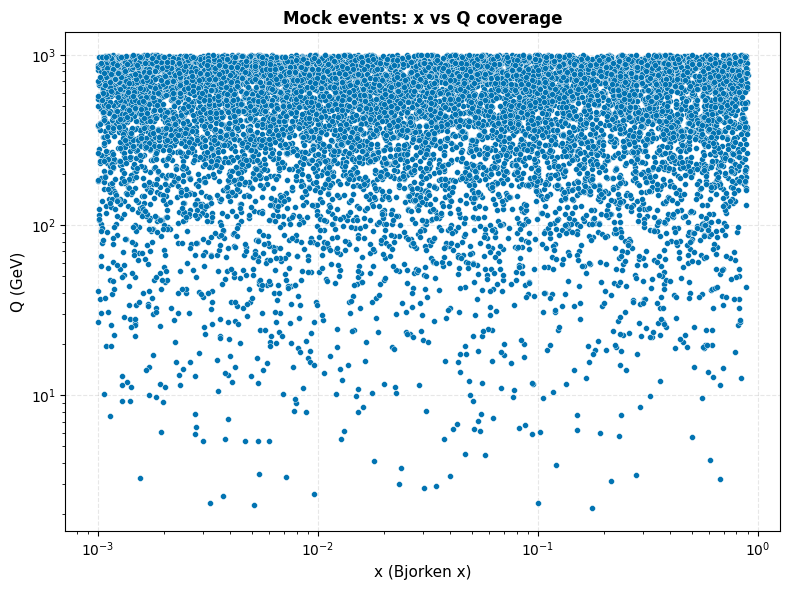

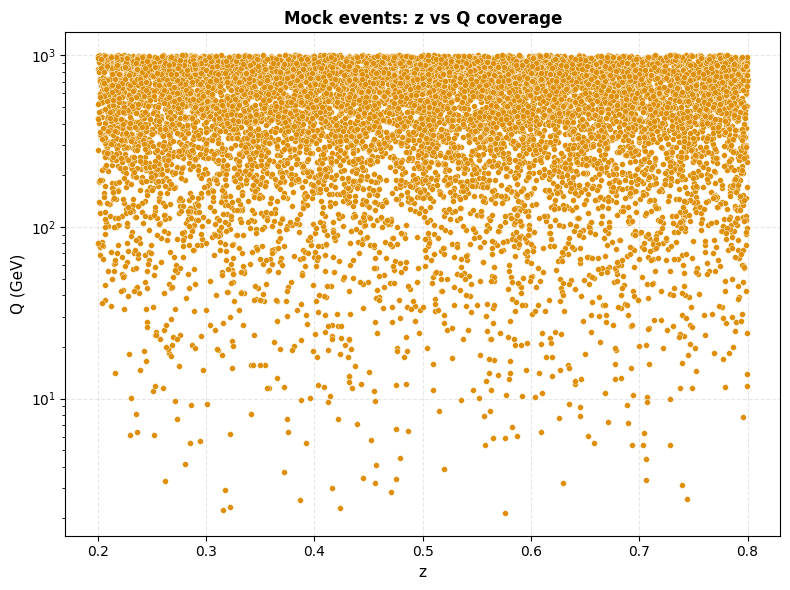

In [7]:
# 2D scatter: x vs Q (SIDIS kinematic coverage)
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor="white")
ax2.scatter(x_plot, Q_plot, s=18, c=colors[0], edgecolors="white", linewidths=0.3)
ax2.set_xlabel("x (Bjorken x)", fontsize=11)
ax2.set_ylabel("Q (GeV)", fontsize=11)
ax2.set_title("Mock events: x vs Q coverage", fontsize=12, fontweight="bold")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# Save the plot
plt.tight_layout()
plt.savefig(plots_dir / f"mock_events_x_vs_Q_coverage_{n_kin_points}.pdf")
plt.show()

# ------------------------------------------------------------------------------------------------

# 2D scatter: z vs Q (SIDIS kinematic coverage)
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor="white")
ax2.scatter(z_plot, Q_plot, s=18, c=colors[1], edgecolors="white", linewidths=0.3)
ax2.set_xlabel(labels[3], fontsize=11)
ax2.set_ylabel("Q (GeV)", fontsize=11)
ax2.set_title("Mock events: z vs Q coverage", fontsize=12, fontweight="bold")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# Save the plot
plt.tight_layout()
plt.savefig(plots_dir / f"mock_events_z_vs_Q_coverage_{n_kin_points}.pdf")
plt.show()

## Section 2: Study fNP parametrizations

### simple exponential parametrization

In [8]:
from IPython.display import display, Math

# --- LaTeX strings (exact functional forms)
latex_pdf = r"\tilde f_{1,\mathrm{NP}}^{\,q}(x,b_T)=\exp\!\left[-\frac{b_T^2}{4}\,\lambda_f^2\,x^{\alpha}(1-x)^2\right]"
latex_ff  = r"\tilde D_{1,\mathrm{NP}}^{\,q}(z,b_T)=\exp\!\left[-\frac{b_T^2}{4}\,\lambda_D^2\,z^{\beta}(1-z)^2\right]"
latex_cs  = r"S(Q,b_T;Q_0)=\exp\!\left[-\frac{b_T^2}{4}\,g_K\,\ln\!\left(\frac{Q^2}{Q_0^2}\right)\right]"

# --- Display as rendered LaTeX in the notebook
display(Math(latex_pdf))
display(Math(latex_ff))
display(Math(latex_cs))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

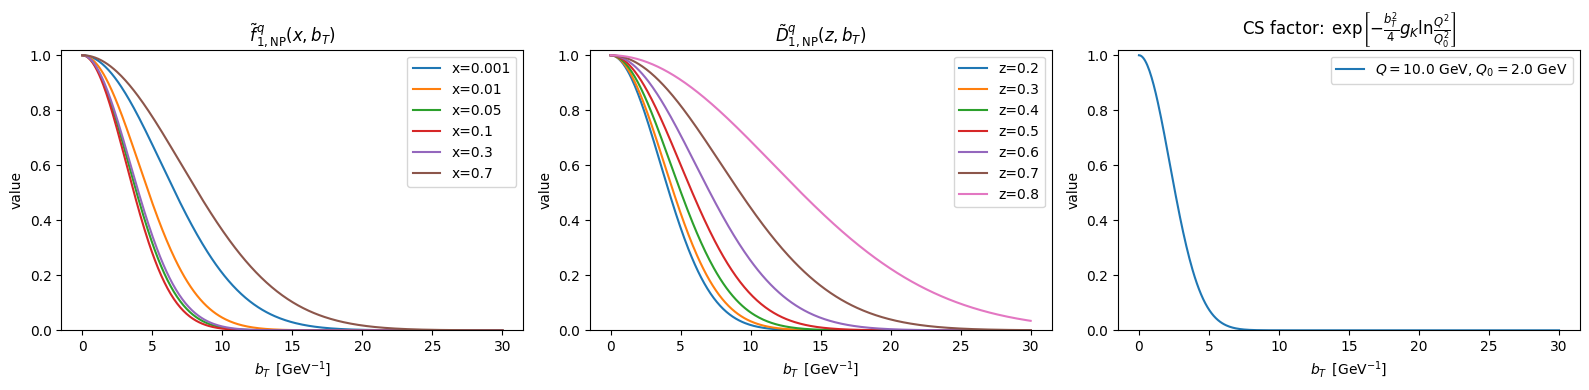

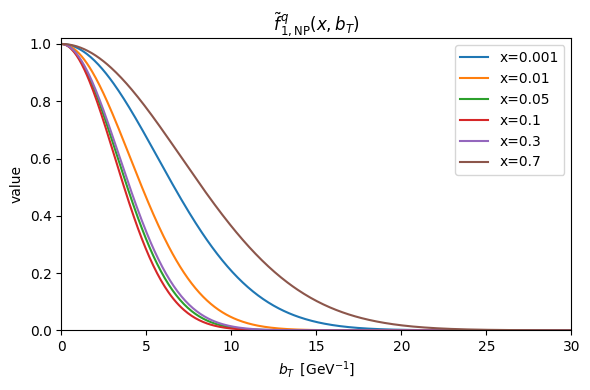

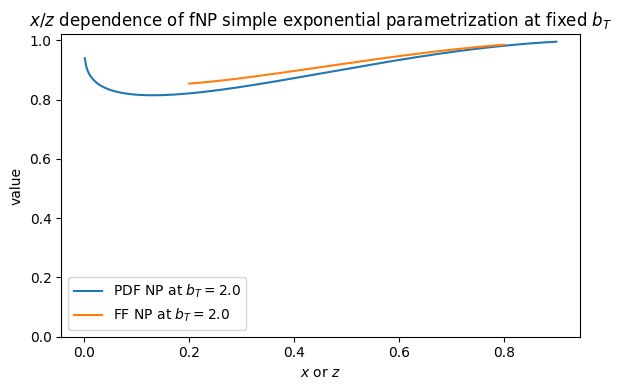

In [9]:

import numpy as np
import matplotlib.pyplot as plt

# --- Parameter choices (edit freely). 
# These are the initial choices for the parameters of the u quark, PDFs and FFs.
lam2_f1 = 0.5   # GeV^2  (lambda_f^2)
alpha   = 0.3
lam2_D1 = 0.4   # GeV^2  (lambda_D^2)
beta    = 0.3
gK      = 0.1284   # GeV^2  (the coefficient in exp[- b_T^2/4 * gK * ln(Q^2/Q0^2)]
Q0      = 2.0      # GeV
Q       = 10.0     # GeV

# --- Grids
x = np.linspace(1e-3, 0.9, 400)
z = np.linspace(0.2, 0.8, 400)
b = np.linspace(0.0, 30.0, 400)  # b_T in GeV^-1

# --- Functional forms (as in your LaTeX)
def fNP_pdf(x, bT, lam2_f1=lam2_f1, alpha=alpha):
    return np.exp(-(bT**2/4.0) * lam2_f1 * (x**(alpha)) * (1.0-x)**2)

def fNP_ff(z, bT, lam2_D1=lam2_D1, beta=beta):
    return np.exp(-(bT**2/4.0) * lam2_D1 * (z**(beta)) * (1.0-z)**2)

def CS_factor(bT, Q=Q, Q0=Q0, gK=gK):
    return np.exp(-(bT**2/4.0) * gK * np.log((Q**2)/(Q0**2)))

# --- Pick a few representative x and z values to show bT-shapes
x_vals = [0.001, 0.01, 0.05, 0.1, 0.3, 0.7]
z_vals = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Set up the multiplot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) PDF NP vs bT for different x
for xv in x_vals:
    axes[0].plot(b, fNP_pdf(xv, b), label=f"x={xv}")
axes[0].set_title(r"$\tilde f^{q}_{1,\mathrm{NP}}(x,b_T)$")
axes[0].set_xlabel(r"$b_T\ \,[\mathrm{GeV}^{-1}]$")
axes[0].set_ylabel("value")
axes[0].set_ylim(0, 1.02)
axes[0].legend()

# 2) FF NP vs bT for different z
for zv in z_vals:
    axes[1].plot(b, fNP_ff(zv, b), label=f"z={zv}")
axes[1].set_title(r"$\tilde D^{q}_{1,\mathrm{NP}}(z,b_T)$")
axes[1].set_xlabel(r"$b_T\ \,[\mathrm{GeV}^{-1}]$")
axes[1].set_ylabel("value")
axes[1].set_ylim(0, 1.02)
axes[1].legend()

# 3) Collins–Soper factor vs bT (single curve)
axes[2].plot(b, CS_factor(b), label=fr"$Q={Q}$ GeV, $Q_0={Q0}$ GeV")
axes[2].set_title(r"CS factor: $\,\exp\!\left[-\frac{b_T^2}{4}g_K\ln\!\frac{Q^2}{Q_0^2}\right]$")
axes[2].set_xlabel(r"$b_T\ \,[\mathrm{GeV}^{-1}]$")
axes[2].set_ylabel("value")
axes[2].set_ylim(0, 1.02)
axes[2].legend()

plt.tight_layout()
plt.savefig(plots_dir / f"fNP_simple_exponential_parametrization.pdf")
plt.show()

# --- Second plot: fnp pdf
plt.figure(figsize=(6,4))
for xv in x_vals:
    plt.plot(b, fNP_pdf(xv, b), label=f"x={xv}")
plt.title(r"$\tilde f^{q}_{1,\mathrm{NP}}(x,b_T)$")
plt.xlabel(r"$b_T\ \,[\mathrm{GeV}^{-1}]$")
plt.ylabel("value")
plt.ylim(0, 1.02)
plt.xlim(0, 30)
plt.legend()
plt.tight_layout()
plt.show()

# --- Third plot: show x-dependence at fixed bT
b0 = 2.0  # GeV^-1
plt.figure(figsize=(6,4))
plt.plot(x, fNP_pdf(x, b0), label=fr"PDF NP at $b_T={b0}$")
plt.plot(z, fNP_ff(z, b0), label=fr"FF NP at $b_T={b0}$")
plt.title(r"$x/z$ dependence of fNP simple exponential parametrization at fixed $b_T$")
plt.xlabel(r"$x$ or $z$")
plt.ylabel("value")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()



#### minor studies

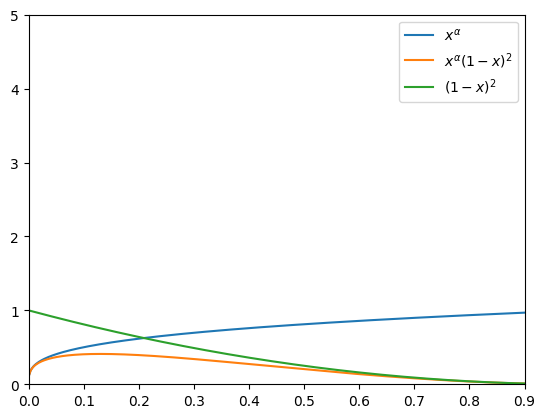

In [10]:
x = np.linspace(0.001, 0.999, 400)

alpha = 0.3

# Plot the function x^(-alpha)
plt.plot(x, x**(alpha), label=r"$x^{\alpha}$")
plt.plot(x, x**(alpha)*(1-x)**2, label=r"$x^{\alpha}(1-x)^2$")
plt.plot(x, (1-x)**2, label=r"$(1-x)^2$")
plt.ylim(0, 5)
plt.xlim(0, 0.9)
plt.legend()
plt.show()


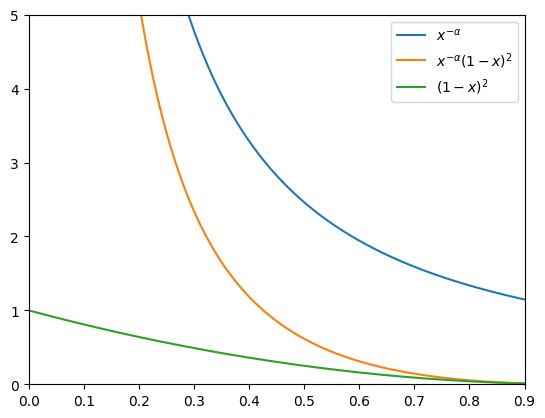

In [11]:
x = np.linspace(0.001, 0.999, 400)

alpha = 1.3

# Plot the function x^(-alpha)
plt.plot(x, x**(-alpha), label=r"$x^{-\alpha}$")
plt.plot(x, x**(-alpha)*(1-x)**2, label=r"$x^{-\alpha}(1-x)^2$")
plt.plot(x, (1-x)**2, label=r"$(1-x)^2$")
plt.ylim(0, 5)
plt.xlim(0, 0.9)
plt.legend()
plt.show()

### PV17 fNP for PDF

In [12]:
# PV17 fNP for PDF
import numpy as np
import matplotlib.pyplot as plt

# --- Central values from  PV17 paper
N1     = 0.28   # GeV^2  (this is the "g1" scale parameter in the table)
alpha  = 2.95   # dimensionless
sigma  = 0.17   # dimensionless
lam    = 0.86   # GeV^-2

# --- Pivot point \hat{x} used in the definition of g1(x)
xhat = .1

# Create subfolder for PV17 plots
pv17_dir = plots_dir / "pv17"
pv17_dir.mkdir(parents=True, exist_ok=True)



#### PV17 definitions

In [13]:
def g1_of_x(x, N1=N1, alpha=alpha, sigma=sigma, xhat=xhat):
    """
    g1(x) = N1 * ( (1-x)^alpha * x^sigma ) / ( (1-xhat)^alpha * xhat^sigma )
    Valid for 0 < x < 1.
    """
    x = np.asarray(x, dtype=float)
    num = (1.0 - x)**alpha * x**sigma
    den = (1.0 - xhat)**alpha * (xhat**sigma)
    return N1 * num / den  # GeV^2

def f1NP_bspace(x, bT, N1=N1, alpha=alpha, sigma=sigma, lam=lam, xhat=xhat):
    """
    \tilde f_{1NP}^a(x,b_T^2) =
      (1/2π) exp[- g1(x) b_T^2 / 4] * ( 1 - [λ g1(x)^2 / (1 + λ g1(x))] * (b_T^2/4) )
    bT in GeV^-1.
    
    The factor (1/2π) is the Fourier transform factor. Without it, the function 
    is normalized to 1 at bT=0.
    """
    x  = np.asarray(x, dtype=float)
    bT = np.asarray(bT, dtype=float)

    g  = g1_of_x(x, N1=N1, alpha=alpha, sigma=sigma, xhat=xhat)  # GeV^2
    t  = (bT**2) / 4.0   # GeV^-2
    fourier_transform_factor = (1.0/(2.0*np.pi))

    return np.exp(-g * t) * (1.0 - (lam * g**2 / (1.0 + lam * g)) * t)
    # return (1.0/(2.0*np.pi)) * np.exp(-g * t) * (1.0 - (lam * g**2 / (1.0 + lam * g)) * t)




#### plots


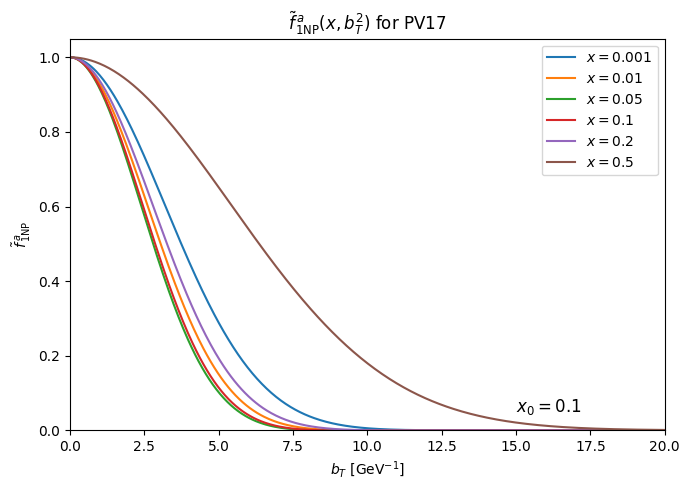

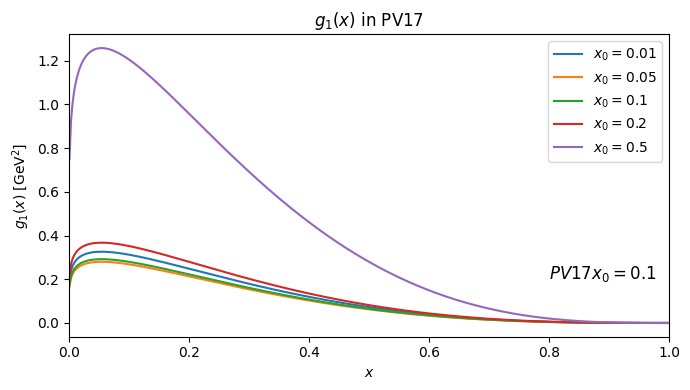

In [14]:
# --- Plot vs bT for several x values
bT = np.linspace(0.0, 20.0, 500)  # GeV^-1
x_list = [0.001, 0.01, 0.05,  0.10, 0.20, 0.50]

plt.figure(figsize=(7,5))
for x in x_list:
    plt.plot(bT, f1NP_bspace(x, bT), label=fr"$x={x}$")

plt.title(r"$\tilde f_{1\mathrm{NP}}^{\,a}(x,b_T^2)$ for PV17")
plt.xlabel(r"$b_T\ [\mathrm{GeV}^{-1}]$")
plt.ylabel(r"$\tilde f_{1\mathrm{NP}}^{\,a}$")
plt.text(15, 0.05, fr"$x_0={xhat}$", fontsize=12)
plt.ylim(bottom=0)
plt.xlim(0, 20)
plt.legend()
plt.tight_layout()
plt.savefig(pv17_dir / f"f1NP_bspace_PV17_x0_{xhat}.pdf")
plt.show()


# Define xgrid
xhat_list = [0.01, 0.05, 0.1, 0.2, 0.5]
xgrid = np.linspace(0.001, 0.999, 400)

# Also plot g1(x) itself to sanity-check the x-shape.
# Plot g1(x) for different x0 values
plt.figure(figsize=(7,4))
for xhat in xhat_list:
    plt.plot(xgrid, g1_of_x(xgrid, xhat=xhat), label=fr"$x_0={xhat}$")
plt.title(r"$g_1(x)$ in PV17")
plt.xlim(0, 1)
plt.xlabel(r"$x$")
plt.ylabel(r"$g_1(x)\ [\mathrm{GeV}^2]$")
plt.text(0.8, 0.2, fr"$PV17 x_0=0.1$", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(pv17_dir / f"g1_of_x_PV17_x0.pdf")
plt.show()


## Section 3 TO MODIFY: Check: Model Initialization with Base Flexible Config

In [15]:
# Initialize the trainable model with flexible config
rootdir = pathlib.Path().resolve().parent

# fnp_config = "fNPconfig_base_flexible.yaml"
fnp_config = "fNPconfig_simple.yaml"

print(f"{tcolors.BOLDWHITE}Initializing model with config: {fnp_config}{tcolors.ENDC}")
model = TrainableModel(fnp_config=fnp_config)

print(f"{tcolors.GREEN}Model initialized successfully!{tcolors.ENDC}")
print(f"Model is in training mode: {model.training}")

Initializing model with config: fNPconfig_simple.yaml

[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_u_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_d_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_s_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_c_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_cb_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_sb_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/sidis/model/../../grids/grids/tmdpdf_db_Q_1.28.txt


[OPE] Initializing OPE
  Grid file: /Users/cbissolotti/anl/projects/tmd/si

## Section 4: Plot Cross Sections

Plot cross sections from a file in the `events/` folder. Specify the number of events to plot. If no YAML in `events/` has `n_events` matching that number, run `generate_mock_events.py` (and `generate_mock_events.py` if needed) to create it.


In [20]:
# Number of events to plot (user specifies)
n_events_to_plot = 10000  # change to 1000, etc. as needed

In [ ]:
import subprocess
import yaml

# Resolve paths for subprocess to find the correct files with respect to the
# running directory. Assumes that this jupyter notebook is in sidis/tests/
events_dir = pathlib.Path().resolve() / "events"
kin_dir = pathlib.Path().resolve() / "kin"
repo_root = pathlib.Path().resolve().parent.parent

# Check if a YAML in events/ has n_events matching our request
yaml_match = None
for f in sorted(events_dir.glob("*.yaml")):
    with open(f) as fp:
        data = yaml.safe_load(fp)
    if data.get("n_events") == n_events_to_plot:
        yaml_match = f
        break

if yaml_match is None:
    print(f"{tcolors.WARNING}No YAML in events/ with n_events={n_events_to_plot}. Generating...{tcolors.ENDC}")
    kin_filename = f"mock_kinematics_{n_events_to_plot}.pt"
    kin_path = kin_dir / kin_filename
    if not kin_path.exists():
        subprocess.run(["python", "sidis/tests/generate_mock_kinematics.py", "-n", str(n_events_to_plot)], check=True, cwd=repo_root)
    subprocess.run(["python", "sidis/tests/generate_mock_events.py", "-e", kin_filename], check=True, cwd=repo_root)
    for f in sorted(events_dir.glob("*.yaml")):
        with open(f) as fp:
            data = yaml.safe_load(fp)
        if data.get("n_events") == n_events_to_plot:
            yaml_match = f
            break

if yaml_match is None:
    raise FileNotFoundError(f"Could not find or generate cross sections for n_events={n_events_to_plot}")

print(f"{tcolors.BOLDGREEN}Using: {yaml_match}{tcolors.ENDC}")

# ------------------------------------------------------------------------------------------------

# Load cross sections and kinematics from the YAML file
with open(yaml_match) as f:
    cs_data = yaml.safe_load(f)

rows = cs_data["data"]
n_events = cs_data["n_events"]
cols = cs_data.get("kinematic_columns", ["x", "PhT", "Q", "z"])

# Build arrays for plotting
x_ev = np.array([r["x"] for r in rows])
PhT_ev = np.array([r["PhT"] for r in rows])
Q_ev = np.array([r["Q"] for r in rows])
z_ev = np.array([r["z"] for r in rows])
xsec = np.array([r["cross_section"] for r in rows])

print(f"{tcolors.BOLDWHITE}Loaded cross sections from file{tcolors.ENDC}")
print(f"  File: {yaml_match}")
print(f"  n_events: {n_events}")
print(f"  Range: [{xsec.min():.4e}, {xsec.max():.4e}]")


#### Check .pt and .yaml cross section files
Add check that the .pt and the .yaml file have the same content. Compare the first 10 points.

In [ ]:
# Add check that the .pt and the .yaml file have the same content. Compare the first 10 points.
# The .pt file lives in events/ alongside the .yaml (same base name)
pt_path = yaml_match.with_suffix(".pt")
pt_data = torch.load(pt_path)

# Get the first 10 points of the .pt file (kinematics: x, PhT, Q, z)
pt_events = pt_data["events"][:10]  # shape (10, 4)

# Get the first 10 points of the .yaml file
yaml_points = rows[:10]

# Compare kinematics: pt has columns [x, PhT, Q, z], yaml has dict keys x, PhT, Q, z
cols = ["x", "PhT", "Q", "z"]
all_match = True

for i in range(min(10, len(rows), pt_events.shape[0])):
    pt_vals = [pt_events[i, j].item() for j in range(4)]
    yaml_vals = [yaml_points[i][c] for c in cols]
    match = all(np.isclose(pt_vals[j], yaml_vals[j]) for j in range(4))
    if not match:
        all_match = False
    status = f"{tcolors.GREEN}✓{tcolors.ENDC}" if match else f"{tcolors.FAIL}✗{tcolors.ENDC}"
    print(f"Point {i+1}: {status}  pt=[{pt_vals[0]:.6f}, {pt_vals[1]:.6f}, {pt_vals[2]:.6f}, {pt_vals[3]:.6f}]  yaml=[{yaml_vals[0]:.6f}, {yaml_vals[1]:.6f}, {yaml_vals[2]:.6f}, {yaml_vals[3]:.6f}]")

if all_match:
    print(f"\n{tcolors.GREEN}All first 10 kinematic points match between .pt and .yaml{tcolors.ENDC}")
else:
    print(f"\n{tcolors.FAIL}Mismatch found between .pt and .yaml kinematics{tcolors.ENDC}")


Point 1: ✓  pt=[0.012779, 3.226908, 374.893537, 0.637999]  yaml=[0.012779, 3.226908, 374.893537, 0.637999]
Point 2: ✓  pt=[0.643636, 2.350533, 334.246272, 0.310707]  yaml=[0.643636, 2.350533, 334.246272, 0.310707]
Point 3: ✓  pt=[0.145374, 4.826043, 177.801605, 0.407984]  yaml=[0.145374, 4.826043, 177.801605, 0.407984]
Point 4: ✓  pt=[0.058692, 1.172994, 608.052137, 0.597968]  yaml=[0.058692, 1.172994, 608.052137, 0.597968]
Point 5: ✓  pt=[0.002890, 2.980496, 477.670912, 0.489254]  yaml=[0.002890, 2.980496, 477.670912, 0.489254]
Point 6: ✓  pt=[0.002890, 3.531029, 865.969590, 0.643143]  yaml=[0.002890, 3.531029, 865.969590, 0.643143]
Point 7: ✓  pt=[0.001485, 4.145266, 34.045361, 0.776725]  yaml=[0.001485, 4.145266, 34.045361, 0.776725]
Point 8: ✓  pt=[0.362155, 2.094158, 644.580192, 0.269928]  yaml=[0.362155, 2.094158, 644.580192, 0.269928]
Point 9: ✓  pt=[0.059681, 3.465917, 763.422981, 0.625741]  yaml=[0.059681, 3.465917, 763.422981, 0.625741]
Point 10: ✓  pt=[0.123543, 1.585687, 75

### Plot cross sections

Number of negative cross sections: 37
Total number of cross sections: 10000

Maximum negative cross section: -2.471584357156112e-08
Minimum cross section         : -2.471584357156112e-08
Minimum negative cross section: -1.1502554367630508e-15


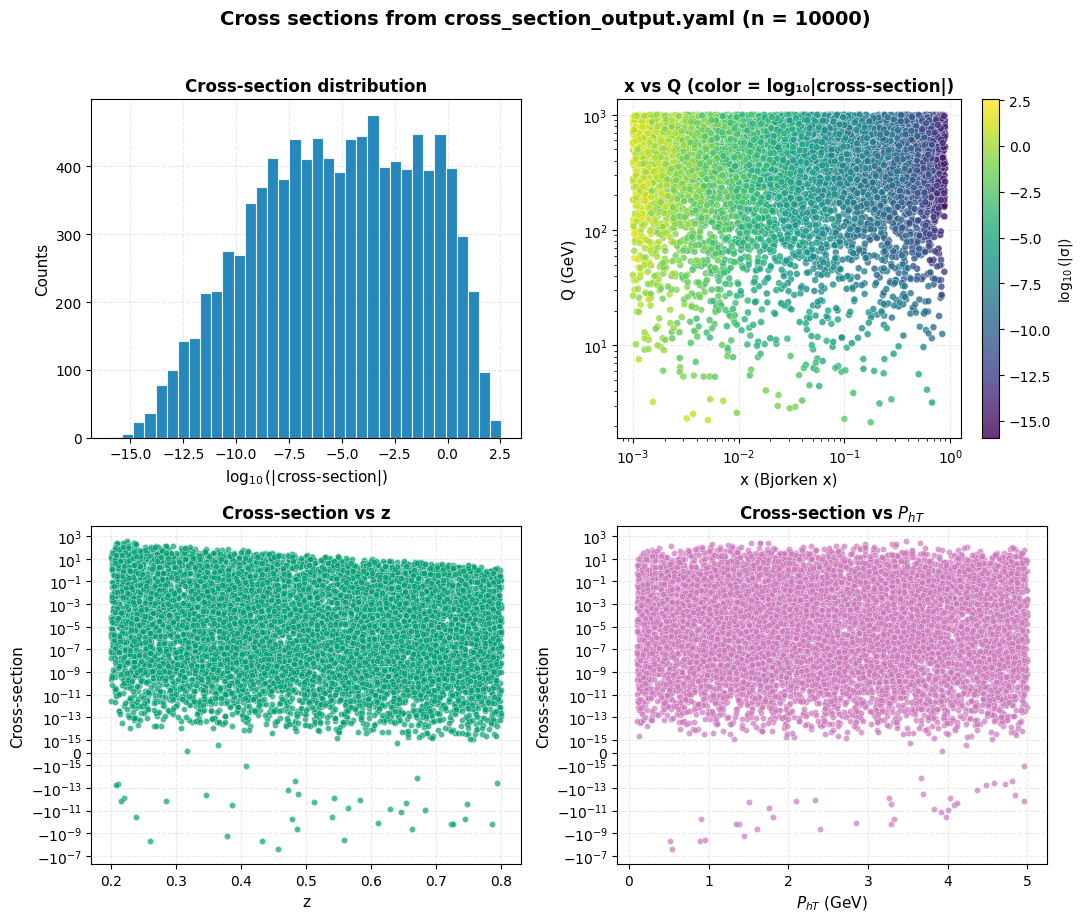

In [ ]:
# Plot cross sections (data loaded from file in previous cell)
# x_ev, PhT_ev, Q_ev, z_ev, xsec, n_events come from the YAML file

# Check for negative values
negative_xsec = xsec[xsec < 0]
print(f"{tcolors.FAIL}Number of negative cross sections: {len(negative_xsec)}{tcolors.ENDC}")
print(f"{tcolors.GREEN}Total number of cross sections: {len(xsec)}{tcolors.ENDC}\n")
if len(negative_xsec) > 0:
    print(f"{tcolors.FAIL}Maximum negative cross section: {negative_xsec.min()}{tcolors.ENDC}")
    print(f"{tcolors.FAIL}Minimum negative cross section: {negative_xsec.max()}{tcolors.ENDC}")

# Use log scale for cross-section (often spans many orders of magnitude)
xsec_plot = np.abs(xsec)
xsec_plot = np.where(xsec_plot > 0, xsec_plot, 1e-30)  # avoid log(0)

# Set up the plot
fig, axes = plt.subplots(2, 2, figsize=(11, 9), facecolor="white")

# Histogram of cross-section (log scale)
axes[0, 0].hist(np.log10(xsec_plot), bins=35, color="#0173b2", edgecolor="white", linewidth=0.8, alpha=0.85)
axes[0, 0].set_xlabel(r"$\log_{10}$(|cross-section|)", fontsize=11)
axes[0, 0].set_ylabel("Counts", fontsize=11)
axes[0, 0].set_title("Cross-section distribution", fontsize=12, fontweight="bold")
axes[0, 0].grid(True, alpha=0.25, linestyle="--")
axes[0, 0].set_axisbelow(True)

# x vs Q colored by cross-section
sc = axes[0, 1].scatter(x_ev, Q_ev, c=np.log10(xsec_plot), cmap="viridis", s=25, alpha=0.8, edgecolors="white", linewidths=0.3)
axes[0, 1].set_xlabel("x (Bjorken x)", fontsize=11)
axes[0, 1].set_ylabel("Q (GeV)", fontsize=11)
axes[0, 1].set_title("x vs Q (color = log₁₀|cross-section|)", fontsize=12, fontweight="bold")
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].grid(True, alpha=0.25, linestyle="--")
plt.colorbar(sc, ax=axes[0, 1], label=r"$\log_{10}$(|σ|)")
axes[0, 1].set_axisbelow(True)

# z vs cross-section (scatter)
axes[1, 0].scatter(z_ev, xsec, s=20, c="#029e73", alpha=0.7, edgecolors="white", linewidths=0.3)
axes[1, 0].set_xlabel("z", fontsize=11)
axes[1, 0].set_ylabel("Cross-section", fontsize=11)
axes[1, 0].set_title("Cross-section vs z", fontsize=12, fontweight="bold")
axes[1, 0].set_yscale("symlog", linthresh=1e-15)
axes[1, 0].grid(True, alpha=0.25, linestyle="--")
axes[1, 0].set_axisbelow(True)

# PhT vs cross-section (scatter)
axes[1, 1].scatter(PhT_ev, xsec, s=20, c="#cc78bc", alpha=0.7, edgecolors="white", linewidths=0.3)
axes[1, 1].set_xlabel(r"$P_{hT}$ (GeV)", fontsize=11)
axes[1, 1].set_ylabel("Cross-section", fontsize=11)
axes[1, 1].set_title(r"Cross-section vs $P_{hT}$", fontsize=12, fontweight="bold")
axes[1, 1].set_yscale("symlog", linthresh=1e-15)
axes[1, 1].grid(True, alpha=0.25, linestyle="--")
axes[1, 1].set_axisbelow(True)

fig.suptitle(f"Cross sections from {yaml_match.name} (n = {n_events})", fontsize=14, fontweight="bold", y=1.02)
plt.savefig(plots_dir / f"cross_sections_from_{yaml_match.stem}.pdf")
plt.tight_layout()
plt.show()


### investigate negative cross sections if necessary

In [24]:
# Boolean mask: True for events with negative cross section
mask = xsec < 0

# Kinematics for negative events
x_neg     = x_ev[mask]
PhT_neg   = PhT_ev[mask]
Q_neg     = Q_ev[mask]
z_neg     = z_ev[mask]
xsec_neg  = xsec[mask]

# Print them
print(f"{tcolors.BOLD}{tcolors.FAIL}Events with negative cross section:{tcolors.ENDC}\n")
for i in range(len(xsec_neg)):
    print(f"  Event {i+1}: x = {x_neg[i]:.6f}, PhT = {PhT_neg[i]:.6f}, Q = {Q_neg[i]:.6f}, z = {z_neg[i]:.6f}  →  σ = {xsec_neg[i]:.4e}")

Events with negative cross section:

  Event 1: x = 0.610357, PhT = 1.814316, Q = 41.373049, z = 0.237863  →  σ = -3.4624e-11
  Event 2: x = 0.697112, PhT = 4.009658, Q = 33.793049, z = 0.682817  →  σ = -9.1548e-12
  Event 3: x = 0.557256, PhT = 3.920730, Q = 39.480958, z = 0.646258  →  σ = -1.3336e-11
  Event 4: x = 0.807646, PhT = 4.811738, Q = 90.797585, z = 0.482248  →  σ = -2.3561e-14
  Event 5: x = 0.617475, PhT = 1.384204, Q = 19.669036, z = 0.721894  →  σ = -1.5406e-10
  Event 6: x = 0.562663, PhT = 4.036251, Q = 102.492214, z = 0.219381  →  σ = -7.5312e-13
  Event 7: x = 0.770565, PhT = 4.723650, Q = 135.132437, z = 0.210928  →  σ = -4.1722e-14
  Event 8: x = 0.576170, PhT = 1.340648, Q = 19.842727, z = 0.786209  →  σ = -1.4794e-10
  Event 9: x = 0.674617, PhT = 3.269790, Q = 51.822641, z = 0.542617  →  σ = -8.4830e-13
  Event 10: x = 0.688533, PhT = 2.337946, Q = 38.182386, z = 0.582627  →  σ = -1.2823e-12
  Event 11: x = 0.616780, PhT = 3.835319, Q = 41.939601, z = 0.628225 